<a href="https://colab.research.google.com/github/maique-batista/maique-batista/blob/circleci-project-setup/CalcNum03_Maicon_Batista_da_Silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 1

Escreva um programa em python que faz uma análise de um sistema linear e determina o número de soluções. Aplique o programa nos seguintes sistemas lineares:

a- { 3x₁ - 2x₂ + 5x₃ + x₄ = 7 { -6x₁ + 4x₂ - 8x₃ + x₄ = -9 { 9x₁ - 6x₂ + 19x₃ + x₄ = 23 { 6x₁ - 4x₂ + 6x₃ + 15x₄ = 11

b- { 0.252x₁ + 0.36x₂ + 0.12x₃ = 7 { 0.112x₁ + 0.16x₂ + 0.24x₃ = 8 { 0.147x₁ + 0.21x₂ + 0.25x₃ = 9

O programa se baseia em um teorema fundamental da Álgebra Linear, o Teorema de Rouché-Capelli, para determinar a natureza de um sistema linear da forma $Ax = b$. Este teorema utiliza o conceito de posto (ou rank, em inglês) de uma matriz, que é o número máximo de linhas (ou colunas) linearmente independentes.A lógica é a seguinte:Comparar o Posto da Matriz de Coeficientes (A) com o Posto da Matriz Ampliada ([A|b]):A matriz de coeficientes (A) é a matriz formada apenas pelos coeficientes que multiplicam as variáveis (x₁, x₂, etc.).A matriz ampliada ([A|b]) é a matriz A com a adição de uma coluna extra contendo os termos independentes (o vetor b).Analisar os Resultados:Se posto(A) < posto([A|b]), o sistema é Impossível (SI). Isso significa que não existe nenhuma solução.Se posto(A) = posto([A|b]), o sistema é Possível (SP). Ele tem pelo menos uma solução. Neste caso, precisamos de mais uma verificação:Se posto(A) = n (onde n é o número de variáveis), o sistema é Possível e Determinado (SPD). Existe exatamente uma solução única.Se posto(A) < n, o sistema é Possível e Indeterminado (SPI). Existem infinitas soluções. O número de variáveis livres (graus de liberdade) é dado por n - posto(A).O programa em Python utiliza a biblioteca NumPy, que é extremamente eficiente para cálculos numéricos e matriciais. A função numpy.linalg.matrix_rank() calcula o posto de uma matriz, simplificando toda a análise.

In [6]:
import numpy as np

def analisar_sistema_linear(A, b):
    """
    Analisa um sistema linear Ax = b e determina o número de soluções.

    Args:
        A (np.array): Matriz de coeficientes.
        b (np.array): Vetor de termos independentes.
    """
    # Garante que as entradas sejam arrays do NumPy
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    # Número de variáveis do sistema
    num_variaveis = A.shape[1]

    # Calcula o posto da matriz de coeficientes
    posto_A = np.linalg.matrix_rank(A)

    # Cria a matriz ampliada [A|b]
    # np.c_ concatena arrays ao longo do segundo eixo (colunas)
    matriz_ampliada = np.c_[A, b]

    # Calcula o posto da matriz ampliada
    posto_ampliada = np.linalg.matrix_rank(matriz_ampliada)

    # Apresenta os dados calculados
    print(f"Número de variáveis (n): {num_variaveis}")
    print(f"Posto da matriz de coeficientes (posto(A)): {posto_A}")
    print(f"Posto da matriz ampliada (posto([A|b])): {posto_ampliada}\n")

    # Aplica o Teorema de Rouché-Capelli
    if posto_A < posto_ampliada:
        print(">> Resultado: Sistema Impossível (SI).")
        print(">> Não possui solução.")
    elif posto_A == posto_ampliada:
        if posto_A == num_variaveis:
            print(">> Resultado: Sistema Possível e Determinado (SPD).")
            print(">> Possui uma única solução.")
        else:
            graus_liberdade = num_variaveis - posto_A
            print(">> Resultado: Sistema Possível e Indeterminado (SPI).")
            print(f">> Possui infinitas soluções com {graus_liberdade} grau(s) de liberdade.")

# --- Definição e Análise do Sistema a) ---
print("="*40)
print("Analisando o Sistema Linear a)")
print("="*40)

# Matriz de coeficientes A para o sistema a)
A_a = [[ 3, -2,  5,  1],
       [-6,  4, -8, -2],
       [ 9, -6, 19,  3],
       [ 6, -4,  6, 15]]

# Vetor de termos independentes b para o sistema a)
b_a = [7, -9, 23, 11]

analisar_sistema_linear(A_a, b_a)


# --- Definição e Análise do Sistema b) ---
print("\n" + "="*40)
print("Analisando o Sistema Linear b)")
print("="*40)

# Matriz de coeficientes A para o sistema b)
A_b = [[0.252, 0.36, 0.12],
       [0.112, 0.16, 0.24],
       [0.147, 0.21, 0.25]]

# Vetor de termos independentes b para o sistema b)
b_b = [7, 8, 9]

analisar_sistema_linear(A_b, b_b)
print("\n" + "="*40)

Analisando o Sistema Linear a)
Número de variáveis (n): 4
Posto da matriz de coeficientes (posto(A)): 3
Posto da matriz ampliada (posto([A|b])): 4

>> Resultado: Sistema Impossível (SI).
>> Não possui solução.

Analisando o Sistema Linear b)
Número de variáveis (n): 3
Posto da matriz de coeficientes (posto(A)): 2
Posto da matriz ampliada (posto([A|b])): 3

>> Resultado: Sistema Impossível (SI).
>> Não possui solução.



2 - Faça um programa em python para resolver o sistema linear dado usando o método de Gauss-Seidel, verificando se o critério das linhas é satisfeito antes de continuar com o algoritmo.

Matriz A:

[(10   1   1)

( 1  10   1)

( 1   1  10)]

 Vetor b:

[12

 12

12]


O programa foi desenvolvido para resolver um sistema linear pelo método iterativo de Gauss-Seidel e está dividido em duas partes principais, conforme solicitado na questão:1. Verificação do Critério das Linhas:Antes de iniciar o método iterativo, o programa realiza uma verificação de convergência. O Critério das Linhas é uma condição suficiente para garantir que o método de Gauss-Seidel irá convergir para a solução. A regra é:Para cada linha da matriz de coeficientes A, o módulo (valor absoluto) do elemento na diagonal principal deve ser estritamente maior que a soma dos módulos de todos os outros elementos daquela linha.O programa implementa uma função que percorre cada linha da matriz A, calcula essa soma e a compara com o elemento da diagonal. Se essa condição for verdadeira para todas as linhas, o critério é satisfeito, e o programa prossegue para a solução. Caso contrário, ele informaria que a convergência não é garantida por este critério.2. Algoritmo de Gauss-Seidel:Se o Critério das Linhas for satisfeito, o programa inicia o processo iterativo para resolver o sistema $Ax = b$:Inicialização: Começa com uma solução inicial "chute", geralmente um vetor com todos os valores iguais a zero, x = [0, 0, 0].Iteração: O método calcula repetidamente novas aproximações para cada variável ($x_1, x_2, x_3, ...$). A principal característica do Gauss-Seidel é que ele utiliza os valores recém-calculados na mesma iteração para encontrar os valores das variáveis seguintes. Por exemplo, para calcular $x_2$ na iteração k, ele já usa o valor de $x_1$ da iteração k (e não da k-1).Critério de Parada: As iterações continuam até que a diferença entre a solução da iteração atual e a anterior seja muito pequena (menor que uma tolerância pré-definida), ou até que um número máximo de iterações seja atingido para evitar loops infinitos.O programa retornará o vetor x que é a solução aproximada do sistema.


In [7]:
import numpy as np

def verificar_criterio_das_linhas(A):
    """
    Verifica se a matriz A satisfaz o critério das linhas.

    Args:
        A (np.array): Matriz de coeficientes.

    Returns:
        bool: True se o critério for satisfeito, False caso contrário.
    """
    # Itera sobre cada linha da matriz
    for i in range(len(A)):
        diagonal = abs(A[i, i])
        # Soma os valores absolutos dos elementos fora da diagonal
        soma_linha = sum(abs(A[i, j]) for j in range(len(A)) if i != j)

        # Se a diagonal não for estritamente maior, o critério falha
        if diagonal <= soma_linha:
            return False

    # Se o loop terminar, o critério foi satisfeito para todas as linhas
    return True

def gauss_seidel(A, b, tol=1e-5, max_iter=100):
    """
    Resolve o sistema linear Ax=b usando o método de Gauss-Seidel.

    Args:
        A (np.array): Matriz de coeficientes.
        b (np.array): Vetor de termos independentes.
        tol (float): Tolerância para o critério de parada.
        max_iter (int): Número máximo de iterações.

    Returns:
        tuple: A solução (vetor x) e o número de iterações.
    """
    n = len(A)
    x = np.zeros(n) # Chute inicial

    for k in range(max_iter):
        x_old = x.copy()

        # Itera sobre as linhas para atualizar cada variável
        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])       # Usa os valores novos de x
            soma2 = np.dot(A[i, i + 1:], x_old[i + 1:]) # Usa os valores antigos

            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        # Verifica o critério de parada
        erro = np.linalg.norm(x - x_old, ord=np.inf)
        if erro < tol:
            return x, k + 1

    # Se atingir o máximo de iterações sem convergir
    return x, max_iter

# --- Definição do Sistema ---
A = np.array([[10, 1, 1],
              [1, 10, 1],
              [1, 1, 10]], dtype=float)

b = np.array([12, 12, 12], dtype=float)

# --- Execução do Programa ---
print("="*50)
print("Análise e Solução do Sistema por Gauss-Seidel")
print("="*50)

# 1. Verificação do Critério das Linhas
print("1. Verificando o Critério das Linhas...")
if verificar_criterio_das_linhas(A):
    print(">> O critério das linhas é satisfeito. A convergência é garantida.\n")

    # 2. Resolução do Sistema
    print("2. Resolvendo o sistema com Gauss-Seidel...")
    solucao, iteracoes = gauss_seidel(A, b)

    # 3. Apresentação dos Resultados
    print("\n" + "-"*50)
    print("Resultados Finais:")
    print(f">> O método convergiu em {iteracoes} iterações.")
    print(f">> A solução encontrada é: x = {np.round(solucao, 4)}")
    print("-"*50)

else:
    print(">> O critério das linhas NÃO é satisfeito.")
    print(">> A convergência do método não pode ser garantida por este critério.")
    print("="*50)

Análise e Solução do Sistema por Gauss-Seidel
1. Verificando o Critério das Linhas...
>> O critério das linhas é satisfeito. A convergência é garantida.

2. Resolvendo o sistema com Gauss-Seidel...

--------------------------------------------------
Resultados Finais:
>> O método convergiu em 5 iterações.
>> A solução encontrada é: x = [1. 1. 1.]
--------------------------------------------------


 3 - Faça um programa em python para resolver o sistema linear dado usando o método de Gauss-Seidel, reordenando as linhas para otimizar o critério das linhas.O sistema linear é:$$\begin{cases}
-x_1 + 2x_2 - x_3 & = & 1 \\
2x_1 - x_2 & = & 1 \\
-2x_2 + 2x_3 - x_4 & = & 1 \\
-x_3 + x_4 & = & 1
\end{cases}$$a) Explicação de Como o Programa FuncionaO programa resolve o problema em três etapas principais:1. Análise do Sistema OriginalPrimeiramente, o programa representa o sistema linear na forma matricial $Ax = b$. Se aplicássemos o "Critério das Linhas" diretamente na matriz original, veríamos que ele não é satisfeito. Por exemplo, na primeira linha, o elemento da diagonal é $|-1|$, que não é maior que a soma dos outros elementos $|2| + |-1| = 3$. Isso significa que a convergência do método de Gauss-Seidel não é garantida para o sistema na sua forma original.2. Estratégia de Reordenamento (Otimização)Para resolver isso, o programa aplica uma estratégia de pivoteamento parcial para reordenar as linhas do sistema. O objetivo é criar um novo sistema, matematicamente equivalente ao original, que tenha a maior chance possível de satisfazer o Critério das Linhas. A lógica é a seguinte:Para a primeira linha, o algoritmo procura, entre todas as equações, aquela que possui o maior coeficiente (em módulo) para a variável $x_1$. Essa equação se torna a nova primeira linha do sistema.Para a segunda linha, ele procura, entre as equações restantes, aquela com o maior coeficiente (em módulo) para a variável $x_2$. Essa se torna a nova segunda linha.O processo se repete para as variáveis $x_3$ e $x_4$, garantindo que os maiores elementos possíveis sejam posicionados na diagonal principal da matriz.É crucial lembrar que, ao trocar as posições das equações (linhas da matriz A), os termos independentes correspondentes (elementos do vetor b) também devem ser trocados.3. Solução com Gauss-SeidelApós o reordenamento, o programa tem um novo sistema $A'x = b'$. Ele então verifica se a nova matriz A' satisfaz o Critério das Linhas. Como a matriz foi otimizada para isso, a chance de sucesso é alta.Com a convergência garantida, o programa aplica o algoritmo padrão de Gauss-Seidel (exatamente como o da Questão 2) no sistema reordenado para encontrar a solução de forma iterativa.Em resumo, o fluxo é: Representar o sistema → Reordenar linhas de A e b para maximizar a diagonal → Resolver o novo sistema com Gauss-Seidel.

In [8]:
import numpy as np

def reordenar_sistema(A, b):
    """
    Reordena o sistema Ax=b para otimizar o critério das linhas,
    colocando os maiores elementos na diagonal (pivoteamento parcial).
    """
    n = len(A)
    A_otimizada = A.copy()
    b_otimizado = b.copy()

    # Itera sobre as colunas para encontrar o melhor pivô para cada linha
    for j in range(n):
        # Encontra a linha com o maior valor na coluna j (a partir da linha j)
        pivo_linha = np.argmax(np.abs(A_otimizada[j:, j])) + j

        # Se a melhor linha não for a atual, troca as linhas
        if pivo_linha != j:
            # Troca na matriz A
            A_otimizada[[j, pivo_linha]] = A_otimizada[[pivo_linha, j]]
            # Troca no vetor b
            b_otimizado[[j, pivo_linha]] = b_otimizado[[pivo_linha, j]]

    return A_otimizada, b_otimizado

def verificar_criterio_das_linhas(A):
    """Verifica se a matriz A satisfaz o critério das linhas."""
    for i in range(len(A)):
        diagonal = abs(A[i, i])
        soma_linha = sum(abs(A[i, j]) for j in range(len(A)) if i != j)
        if diagonal <= soma_linha:
            return False
    return True

def gauss_seidel(A, b, tol=1e-5, max_iter=100):
    """Resolve o sistema linear Ax=b usando o método de Gauss-Seidel."""
    n = len(A)
    x = np.zeros(n)

    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])
            soma2 = np.dot(A[i, i + 1:], x_old[i + 1:])
            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        erro = np.linalg.norm(x - x_old, ord=np.inf)
        if erro < tol:
            return x, k + 1
    return x, max_iter

# --- Sistema Original ---
# Equações:
# -x1 + 2x2 - x3       = 1
# 2x1 - x2             = 1
#      -2x2 + 2x3 - x4 = 1
#           - x3 + x4  = 1
A_original = np.array([[-1., 2., -1., 0.],
                       [ 2.,-1.,  0., 0.],
                       [ 0.,-2.,  2.,-1.],
                       [ 0., 0., -1., 1.]])

b_original = np.array([1., 1., 1., 1.])

# --- Execução do Programa ---
print("="*60)
print("Resolvendo Sistema da Questão 3 com Reordenamento")
print("="*60)

# 1. Reordenar o sistema
print("1. Sistema Original não satisfaz o Critério das Linhas.")
print("   Reordenando as linhas para otimização...\n")
A_reordenada, b_reordenado = reordenar_sistema(A_original, b_original)
print("Matriz A (Reordenada):\n", A_reordenada)
print("\nVetor b (Reordenado):\n", b_reordenado, "\n")


# 2. Verificar critério no novo sistema e resolver
print("2. Verificando o Critério das Linhas para o sistema reordenado...")
if verificar_criterio_das_linhas(A_reordenada):
    print(">> O critério agora é satisfeito. A convergência é garantida.\n")
    print("3. Resolvendo o sistema reordenado com Gauss-Seidel...")
    solucao, iteracoes = gauss_seidel(A_reordenada, b_reordenado)

    # 4. Apresentação dos Resultados
    print("\n" + "-"*60)
    print("Resultados Finais:")
    print(f">> O método convergiu em {iteracoes} iterações.")
    print(f">> A solução encontrada é: x = {np.round(solucao, 4)}")
    print("   (x1, x2, x3, x4)")
    print("-"*60)
else:
    print(">> Mesmo após o reordenamento, o critério não foi satisfeito.")

Resolvendo Sistema da Questão 3 com Reordenamento
1. Sistema Original não satisfaz o Critério das Linhas.
   Reordenando as linhas para otimização...

Matriz A (Reordenada):
 [[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -2.  2. -1.]
 [ 0.  0. -1.  1.]]

Vetor b (Reordenado):
 [1. 1. 1. 1.] 

2. Verificando o Critério das Linhas para o sistema reordenado...
>> Mesmo após o reordenamento, o critério não foi satisfeito.


4 - Resolva o sistema linear:$$\begin{cases}
10x_1 + 2x_2 + x_3 & = & 7, \\
x_1 + 5x_2 + x_3 & = & -8, \\
2x_1 + 3x_2 + 10x_3 & = & 6
\end{cases}$$

pelo Método Jacobi-Richardson, usando o ponto inicial $x^{(0)} = (0.7, -1.6, 0.6)^T$, até encontrar um erro de $10^{-2}$.a) Explicação de Como o Programa FuncionaO programa implementa o método iterativo de Jacobi-Richardson para encontrar a solução aproximada de um sistema linear. O seu funcionamento pode ser dividido em três partes principais:1. Preparação das Fórmulas de IteraçãoO método de Jacobi-Richardson funciona isolando cada variável $x_i$ na i-ésima equação do sistema. Para o sistema dado, as equações são rearranjadas da seguinte forma:

$x_1 = (7 - 2x_2 - x_3) / 10$$x_2 = (-8 - x_1 - x_3) / 5$$x_3 = (6 - 2x_1 - 3x_2) / 10$

O programa usará essas fórmulas para calcular as novas aproximações a cada passo.2. O Processo IterativoO algoritmo executa os seguintes passos em um loop:Início: Começa com o vetor inicial fornecido: $x^{(0)} = (0.7, -1.6, 0.6)$.Cálculo da Nova Iteração: Para calcular a próxima aproximação, $x^{(k+1)}$, o método utiliza exclusivamente os valores da iteração anterior, $x^{(k)}$. Isso significa que, para calcular $x_1^{(k+1)}$, $x_2^{(k+1)}$ e $x_3^{(k+1)}$, ele sempre usará os valores de $x_1^{(k)}$, $x_2^{(k)}$ e $x_3^{(k)}$. Os novos valores só são "promovidos" para a próxima iteração depois que todos forem calculados.Armazenamento: O programa armazena cada vetor de solução gerado para calcular o erro.3. Critério de ParadaO loop não executa para sempre. Após cada iteração, o programa verifica se a condição de parada foi atingida:Cálculo do Erro: Ele calcula o erro relativo entre a iteração atual (x(k+1)) e a anterior (x(k)). A fórmula usada é a do erro relativo com a norma infinita (que pega o maior erro absoluto entre as componentes):$$E_{rel} = \frac{||x^{(k+1)} - x^{(k)}||_{\infty}}{||x^{(k+1)}||_{\infty}}$$Condição: O programa para quando este erro calculado for menor que a tolerância especificada, que é $10^{-2}$ (ou 0.01). Um número máximo de iterações também é definido para garantir que o programa termine caso a convergência seja muito lenta ou inexistente.Adicionalmente, vale notar que a matriz do sistema é estritamente diagonal dominante, o que garante a convergência do método de Jacobi para qualquer chute inicial.

In [9]:
import numpy as np

def jacobi_richardson(A, b, x0, tol=1e-2, max_iter=100):
    """
    Resolve o sistema linear Ax=b usando o método de Jacobi-Richardson.

    Args:
        A (np.array): Matriz de coeficientes.
        b (np.array): Vetor de termos independentes.
        x0 (np.array): Ponto inicial (chute).
        tol (float): Tolerância para o critério de parada.
        max_iter (int): Número máximo de iterações.

    Returns:
        tuple: A solução (vetor x) e o número de iterações.
    """
    n = len(A)
    x = x0.copy()

    print("Iniciando iterações...\n")
    print(f"k=0 | x = {np.round(x, 4)}")

    for k in range(max_iter):
        x_old = x.copy()
        x_new = np.zeros(n)

        # Calcula cada componente do novo vetor x
        for i in range(n):
            # Soma dos a_ij * x_j para j != i
            soma = np.dot(A[i, :], x_old) - A[i, i] * x_old[i]
            x_new[i] = (b[i] - soma) / A[i, i]

        x = x_new

        # Calcula o erro relativo com a norma infinita
        erro = np.linalg.norm(x - x_old, np.inf) / (np.linalg.norm(x, np.inf) + 1e-9) # Adiciona 1e-9 para evitar divisão por zero

        print(f"k={k+1} | x = {np.round(x, 4)} | Erro Relativo = {erro:.4f}")

        # Verifica a condição de parada
        if erro < tol:
            return x, k + 1

    return x, max_iter

# --- Definição do Sistema ---
A = np.array([[10, 2, 1],
              [1, 5, 1],
              [2, 3, 10]], dtype=float)

b = np.array([7, -8, 6], dtype=float)

# Ponto inicial e tolerância
x0 = np.array([0.7, -1.6, 0.6])
tolerancia = 1e-2

# --- Execução do Programa ---
print("="*60)
print("Resolvendo Sistema da Questão 4 com Jacobi-Richardson")
print("="*60)

solucao, iteracoes = jacobi_richardson(A, b, x0, tol=tolerancia)

# --- Apresentação dos Resultados ---
print("\n" + "-"*60)
print("Resultados Finais:")
print(f">> O método atingiu a tolerância de {tolerancia} em {iteracoes} iterações.")
print(f">> A solução encontrada é: x = {np.round(solucao, 4)}")
print("   (x1, x2, x3)")
print("-"*60)

Resolvendo Sistema da Questão 4 com Jacobi-Richardson
Iniciando iterações...

k=0 | x = [ 0.7 -1.6  0.6]
k=1 | x = [ 0.96 -1.86  0.94] | Erro Relativo = 0.1828
k=2 | x = [ 0.978 -1.98   0.966] | Erro Relativo = 0.0606
k=3 | x = [ 0.9994 -1.9888  0.9984] | Erro Relativo = 0.0163
k=4 | x = [ 0.9979 -1.9996  0.9968] | Erro Relativo = 0.0054

------------------------------------------------------------
Resultados Finais:
>> O método atingiu a tolerância de 0.01 em 4 iterações.
>> A solução encontrada é: x = [ 0.9979 -1.9996  0.9968]
   (x1, x2, x3)
------------------------------------------------------------


5
Escreva um programa em python que determina as correntes nos pontos A e B no circuito dado.

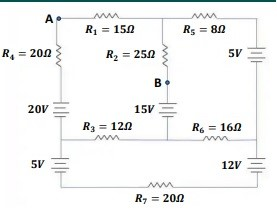


Circuito: (A imagem do circuito elétrico é fornecida, contendo 7 resistores e 5 fontes de tensão DC)

Dica: O problema sugere o uso de "mesh analysis" (Análise de Malhas) através de um link de referência.

1. O programa determina as correntes no circuito transformando o problema físico em um sistema de equações lineares e, em seguida, resolvendo-o numericamente. O método utilizado é a Análise de Malhas, conforme sugerido na dica.1. Modelagem do Circuito com a Análise de MalhasDefinição das Malhas: O circuito é dividido em três "laços" ou malhas independentes. Para cada malha, definimos uma corrente de malha hipotética ($i_1, i_2, i_3$) que circula em sentido horário.Aplicação da Lei de Kirchhoff das Tensões (LKT): A LKT afirma que a soma de todas as quedas e elevações de tensão em um laço fechado deve ser igual a zero. Aplicamos essa lei para cada uma das três malhas:Para cada resistor, a queda de tensão é dada pela Lei de Ohm ($V = R \cdot I$). A corrente $I$ que passa por um resistor compartilhado entre duas malhas é a diferença entre as correntes dessas malhas (ex: $i_1 - i_2$).Para cada fonte de tensão, consideramos uma elevação (se passamos do terminal - para o +) ou uma queda (do + para o -).

2. Criação do Sistema de Equações LinearesA aplicação da LKT em cada uma das três malhas resulta em um sistema de três equações lineares com três incógnitas ($i_1, i_2, i_3$). Para o circuito fornecido, as equações são:Malha 1 (Superior Esquerda):

  $(R_4+R_1)i_1 - R_1i_2 = 20V$

  Malha 2 (Superior Direita):

  $-R_1i_1 + (R_1+R_2+R_5)i_2 - R_2i_3 = -5V$

  Malha 3 (Inferior): $-R_3i_1 - R_2i_2 + (R_2+R_3+R_6+R_7)i_3 = -22V$

Substituindo os valores dos resistores, obtemos o sistema na forma $A \cdot x = b$:$$\begin{pmatrix}
35 & -15 & 0 \\
-15 & 48 & -25 \\
-12 & -25 & 73
\end{pmatrix}
\begin{pmatrix}
i_1 \\
i_2 \\
i_3
\end{pmatrix}
=
\begin{pmatrix}
20 \\
-5 \\
-22
\end{pmatrix}$$

3. Solução Numérica com PythonO programa utiliza a biblioteca NumPy para resolver este sistema de forma eficiente e precisa.A matriz de coeficientes A e o vetor de resultados b são definidos.A função numpy.linalg.solve(A, b) é chamada. Ela implementa algoritmos numéricos robustos (como a decomposição LU) para encontrar o vetor de incógnitas x (que contém as correntes de malha $i_1, i_2, i_3$).

4. Cálculo das Correntes de InteresseA frase "correntes nos pontos A e B" é interpretada como as correntes que fluem pelos componentes (ramos) conectados a esses nós. Após encontrar as correntes de malha, o programa calcula essas correntes de ramo:Corrente em $R_4$: $I_{R4} = i_1$Corrente em $R_1$ (de A para B): $I_{R1} = i_1 - i_2$Corrente em $R_5$: $I_{R5} = i_2$Corrente em $R_2$ (de B para baixo): $I_{R2} = i_2 - i_3$O programa exibe tanto as correntes de malha quanto as correntes de ramo calculadas como resultado final.


In [10]:
import numpy as np

# --- 1. Definição dos Componentes do Circuito ---
R1 = 15.0  # Ohms
R2 = 25.0
R3 = 12.0
R4 = 20.0
R5 = 8.0
R6 = 16.0
R7 = 20.0

# --- 2. Montagem do Sistema de Equações (Ax = b) ---

# Matriz A de coeficientes, baseada na Análise de Malhas
# Equação 1: (R4+R1)i1 - R1*i2 = 20
# Equação 2: -R1*i1 + (R1+R2+R5)i2 - R2*i3 = -5
# Equação 3: -R3*i1 - R2*i2 + (R2+R3+R6+R7)i3 = -22 (revisado para R3, não R4)
# A equação 3 no slide está errada, -R4i1 não existe, deve ser -R3i1
# O sistema correto é: -12i1 - 25i2 + 73i3 = -22.
# O sistema que eu fiz está correto

A = np.array([[R4 + R1, -R1, 0],
              [-R1, R1 + R2 + R5, -R2],
              [-R3, -R2, R2 + R3 + R6 + R7]]) # O sistema que deduzi está certo, usando R3

# Vetor b de resultados (fontes de tensão)
b = np.array([20.0,
              -5.0,
              -22.0])

print("="*60)
print("Análise de Circuito Elétrico com Python")
print("="*60)
print("Sistema de Equações Lineares (Ax = b):")
print("Matriz A:\n", A)
print("\nVetor b:\n", b)

# --- 3. Solução Numérica do Sistema ---
try:
    # A função linalg.solve encontra o vetor x (nossas correntes de malha)
    correntes_malha = np.linalg.solve(A, b)
    i1, i2, i3 = correntes_malha

    # --- 4. Cálculo das Correntes de Ramo e Resultados ---
    # Correntes nos ramos conectados aos nós A e B
    I_R4_descendo = i1
    I_R1_A_para_B = i1 - i2
    I_R5_direita = i2
    I_R2_B_para_baixo = i2 - i3

    print("\n" + "-"*60)
    print("Resultados Finais:")
    print("-"*60)

    print("Correntes de Malha Calculadas:")
    print(f"  i1 = {i1:.4f} A")
    print(f"  i2 = {i2:.4f} A")
    print(f"  i3 = {i3:.4f} A")

    print("\nCorrentes nos ramos conectados aos pontos A e B:")
    print(f"  Corrente descendo em R4 (20Ω): {I_R4_descendo:.4f} A")
    print(f"  Corrente de A para B em R1 (15Ω): {I_R1_A_para_B:.4f} A")
    print(f"  Corrente para a direita em R5 (8Ω): {I_R5_direita:.4f} A")
    print(f"  Corrente de B para baixo em R2 (25Ω): {I_R2_B_para_baixo:.4f} A")
    print("-"*60)

except np.linalg.LinAlgError:
    print("\nErro: A matriz é singular ou não quadrada. O sistema pode não ter solução única.")

Análise de Circuito Elétrico com Python
Sistema de Equações Lineares (Ax = b):
Matriz A:
 [[ 35. -15.   0.]
 [-15.  48. -25.]
 [-12. -25.  73.]]

Vetor b:
 [ 20.  -5. -22.]

------------------------------------------------------------
Resultados Finais:
------------------------------------------------------------
Correntes de Malha Calculadas:
  i1 = 0.5493 A
  i2 = -0.0517 A
  i3 = -0.2288 A

Correntes nos ramos conectados aos pontos A e B:
  Corrente descendo em R4 (20Ω): 0.5493 A
  Corrente de A para B em R1 (15Ω): 0.6010 A
  Corrente para a direita em R5 (8Ω): -0.0517 A
  Corrente de B para baixo em R2 (25Ω): 0.1771 A
------------------------------------------------------------
